# Random Forest Classifier

- Random_Forest: builds many decision trees on random subsets of data/features, then averages their votes
- Reduces overfitting compared to a single Decision Tree, more stable predictions
- Dataset: Churn_Modelling.csv (predicting Exited — whether a customer left the bank)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Churn_Modelling.csv')
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


## EDA

In [ ]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
df.duplicated().sum()

np.int64(0)

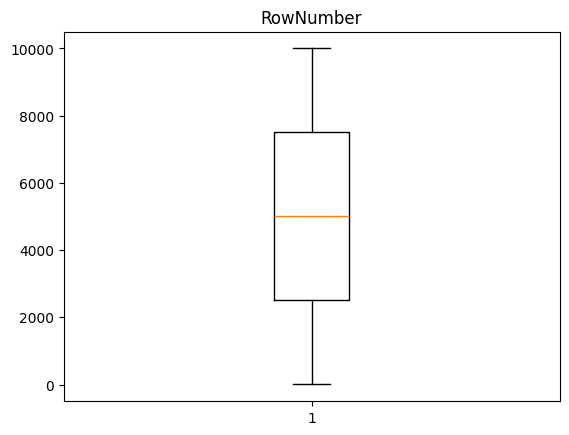

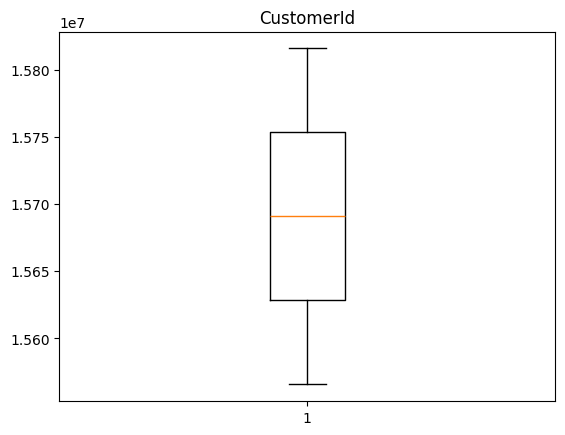

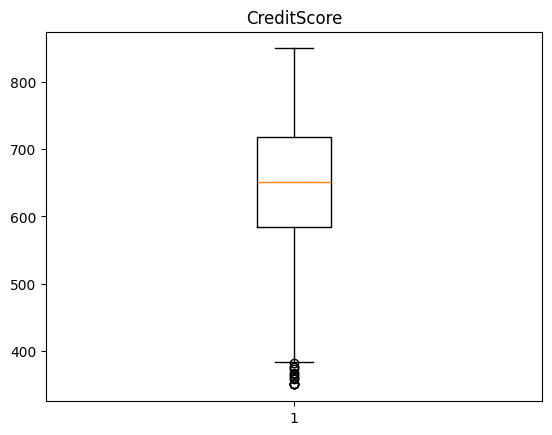

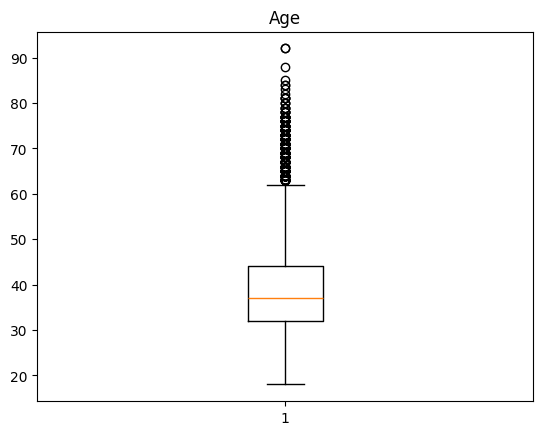

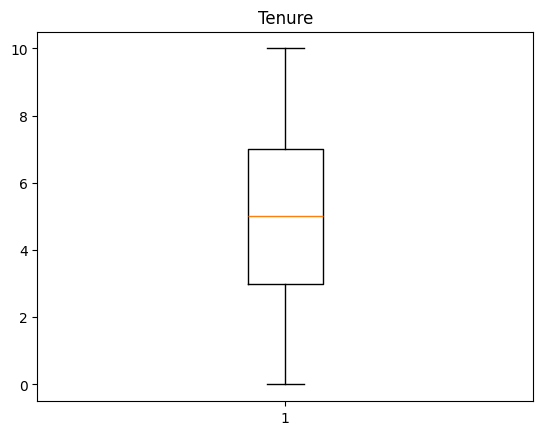

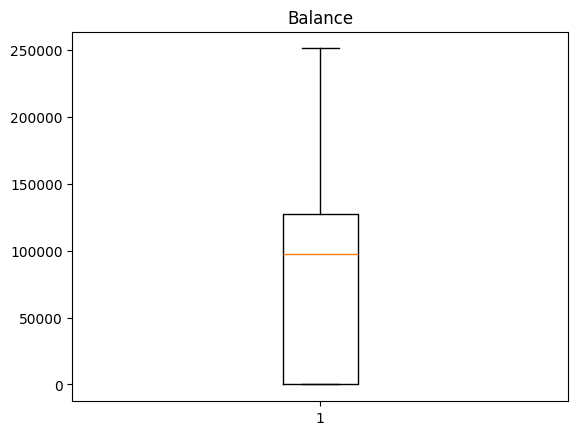

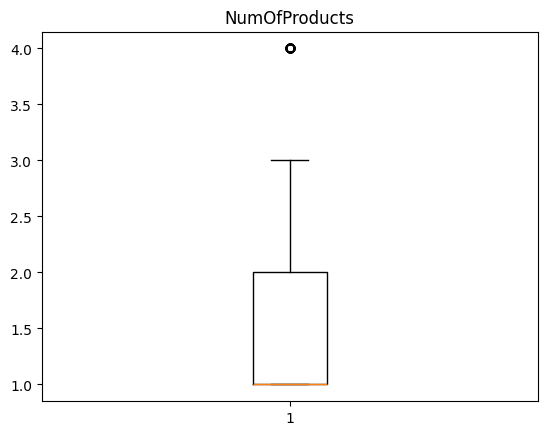

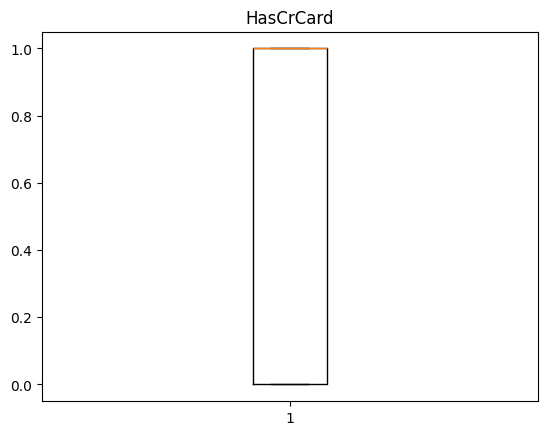

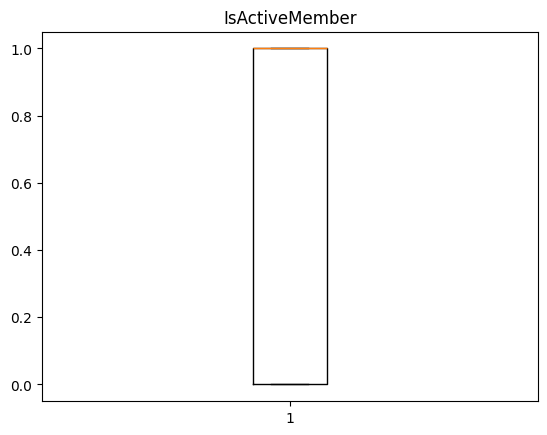

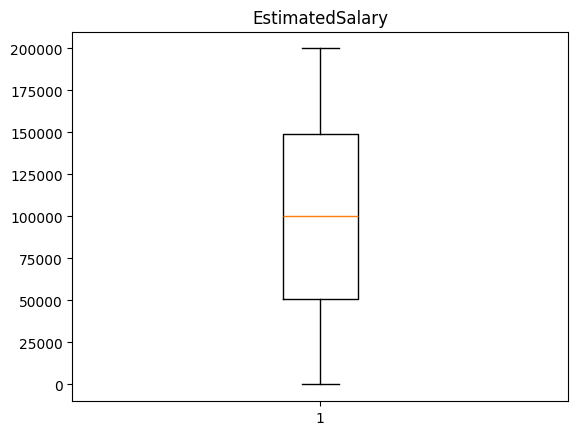

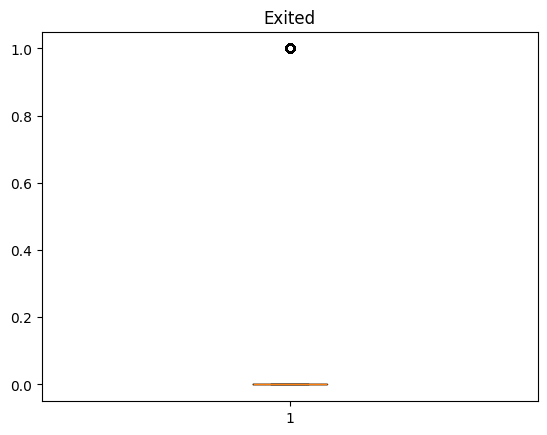

In [ ]:
for col in df.columns:
  if df[col].dtypes != 'object':
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

X = df.drop("Exited", axis=1)
Y = df["Exited"]

## Model Building
problem statement - A bank wants to know which customers are likely to leave (churn). For each customer, the bank has data like Credit Score, Geography, Gender, Age, Tenure, Account Balance, Number of Products, Credit Card ownership, and Activity status, along with whether they eventually exited the bank. The goal is to build a Random Forest classifier that predicts whether a customer will exit, so the bank can proactively intervene to retain at-risk customers.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)
print(pd.DataFrame({"Actual": Y_test, "Predicted": Y_pred}))

cm = confusion_matrix(Y_test, Y_pred)
acc = accuracy_score(Y_test, Y_pred)
print("Confusion Matrix:\n", cm)
print("Accuracy:", round(acc, 4))

Train size: 8000
Test size : 2000
      Actual  Predicted
6252       0          0
4684       0          0
1731       0          0
4742       0          0
4521       0          0
...      ...        ...
6412       1          1
8285       0          0
7853       1          1
1095       1          0
6929       1          0

[2000 rows x 2 columns]
Confusion Matrix:
 [[1551   56]
 [ 211  182]]
Accuracy: 0.8665


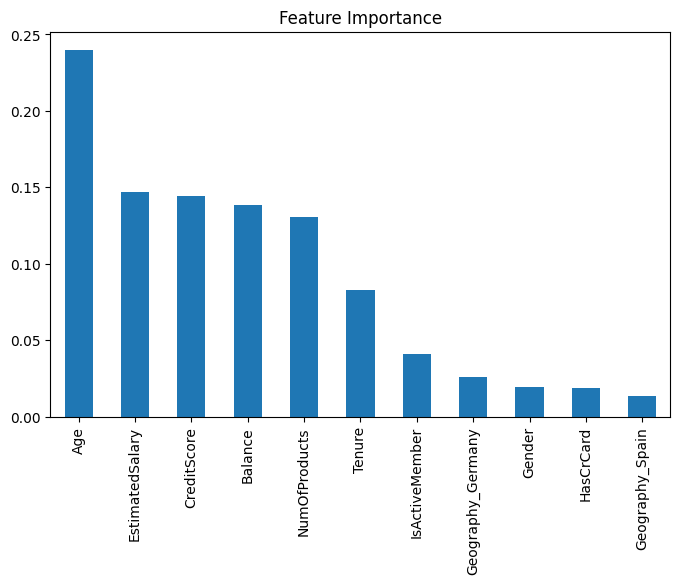

Age                  0.239783
EstimatedSalary      0.146638
CreditScore          0.144214
Balance              0.138613
NumOfProducts        0.130255
Tenure               0.082427
IsActiveMember       0.041110
Geography_Germany    0.025711
Gender               0.019258
HasCrCard            0.018722
Geography_Spain      0.013268
dtype: float64


In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importances.plot(kind="bar")
plt.title("Feature Importance")
plt.show()
print(importances)

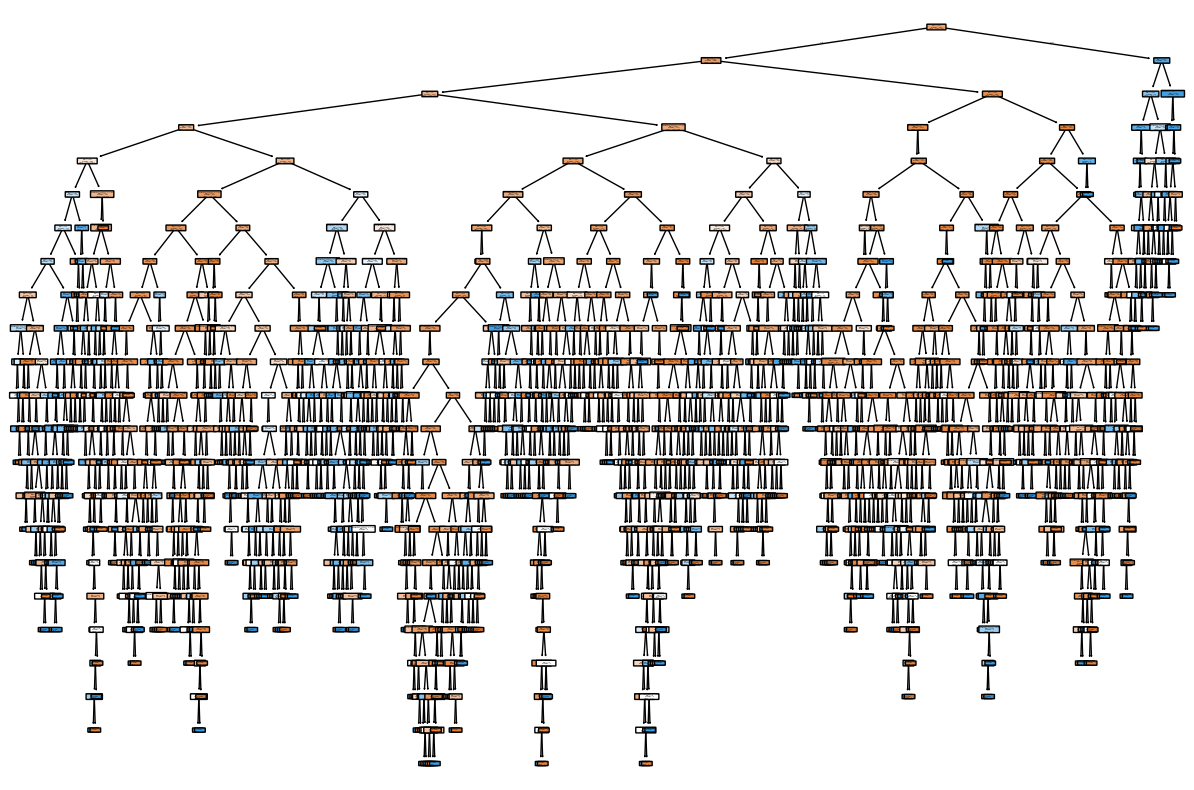

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(model.estimators_[0], feature_names=X.columns, filled=True, rounded=True)
plt.show()

## Conclusion
- Random Forest trained 100 decision trees on random subsets of data/features and averaged their votes
- Confusion Matrix & Accuracy show how well it predicted on unseen test data
- Feature importance shows which features (e.g. Age, Balance, CreditScore) drove churn predictions the most
- With more real-world features, Random Forest tends to be more robust and less prone to overfitting than a single Decision Tree